In [1]:
from IPython.display import HTML
HTML("""
<style>

/* 1️⃣ 让整体容器铺满 */
.container {
    width: 100% !important;
    max-width: 100% !important;
}

/* 2️⃣ 代码输入区自动换行 */
div.input_area pre {
    white-space: pre-wrap !important;
    word-break: break-word !important;
}

/* 3️⃣ 代码高亮区域也处理 */
div.highlight pre {
    white-space: pre-wrap !important;
    word-break: break-word !important;
}

/* 4️⃣ 防止代码块横向撑破 */
div.input_area {
    overflow-x: auto;
}

/* 5️⃣ 表格横向滚动 */
table {
    display: block;
    overflow-x: auto;
}

</style>
""")

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [35]:
from mpl_toolkits.mplot3d import Axes3D

In [36]:
rfm = pd.read_csv('./RFM_DATA.csv')

In [37]:
rfm

,Order Date,Customer Name,Sales,Profit,R_value,F_value,M_Sales,M_Profit,R_Score,F_Score,M_Score_Sales,M_Score_Profit,M_score_Sales是否等于M_score_Profit
0,2014/1/3,Darren Powers,16.448,5.5512,126,17,1050.636,241.4524,2,3,1,3,N
1,2014/1/4,Phillina Ober,11.784,4.2717,86,10,1056.858,-49.7009,3,1,1,1,Y
2,2014/1/4,Phillina Ober,272.736,-64.7748,86,10,1056.858,-49.7009,3,1,1,1,Y
3,2014/1/4,Phillina Ober,3.540,-5.4870,86,10,1056.858,-49.7009,3,1,1,1,Y
4,2014/1/5,Mick Brown,19.536,4.8840,44,10,1428.231,117.8057,3,1,2,2,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,2017/12/30,Erica Bern,20.720,6.4750,0,6,1643.255,162.8781,5,1,2,2,Y
9990,2017/12/30,Jill Matthias,3.024,-0.6048,0,7,303.948,113.1204,5,1,1,2,N
9991,2017/12/30,Patrick O'Donnell,323.136,12.1176,0,13,2493.214,437.8533,5,2,3,4,N
9992,2017/12/30,Patrick O'Donnell,90.930,2.7279,0,13,2493.214,437.8533,5,2,3,4,N


In [38]:
rfm.columns

Index(['Order Date', 'Customer Name', 'Sales', 'Profit', 'R_value', 'F_value',
       'M_Sales', 'M_Profit', 'R_Score', 'F_Score', 'M_Score_Sales',
       'M_Score_Profit', 'M_score_Sales是否等于M_score_Profit'],
      dtype='object')

In [39]:
rfm1 = rfm[['Customer Name','R_Score', 'F_Score', 'M_Score_Sales']]
rfm1 = rfm1.drop_duplicates()

In [40]:
rfm1

,Customer Name,R_Score,F_Score,M_Score_Sales
0,Darren Powers,2,3,1
1,Phillina Ober,3,1,1
4,Mick Brown,3,1,2
5,Jack O'Briant,3,2,3
6,Lycoris Saunders,1,1,1
...,...,...,...,...
7921,Jenna Caffey,2,1,1
8559,Theresa Coyne,2,1,1
8979,Patricia Hirasaki,3,1,1
9005,Jocasta Rupert,3,1,1


In [41]:
rfm2 = rfm[['Customer Name','R_Score', 'F_Score', 'M_Score_Profit']]
rfm2 = rfm2.drop_duplicates()
rfm2

,Customer Name,R_Score,F_Score,M_Score_Profit
0,Darren Powers,2,3,3
1,Phillina Ober,3,1,1
4,Mick Brown,3,1,2
5,Jack O'Briant,3,2,4
6,Lycoris Saunders,1,1,2
...,...,...,...,...
7921,Jenna Caffey,2,1,4
8559,Theresa Coyne,2,1,3
8979,Patricia Hirasaki,3,1,2
9005,Jocasta Rupert,3,1,2


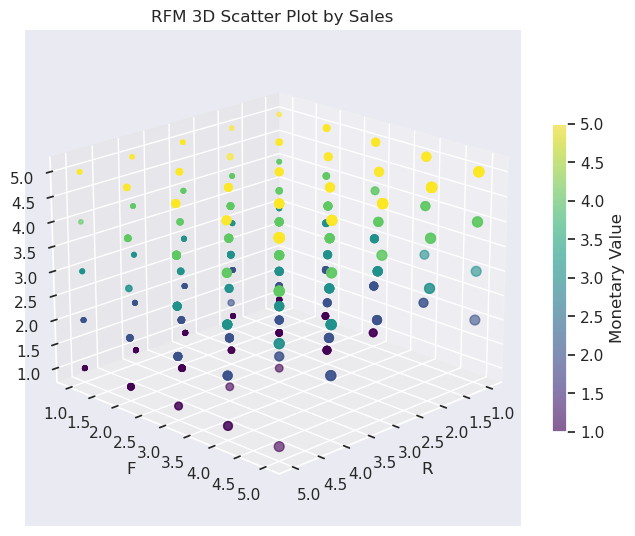

In [42]:
# 1. 创建图形和3D坐标轴
fig = plt.figure(figsize=(8, 8)) # 可以调整图形大小
ax = fig.add_subplot(111, projection='3d')

# 2. 绘制散点图
# 使用ax.scatter，分别传入R, F, M的值作为x, y, z坐标。
# 参数c可以指定颜色映射的依据，这里我们用'M'值（消费金额），让颜色代表客户价值高低。
# 参数cmap选择颜色映射，例如'viridis'。
# 参数s可以指定点的大小。
scatter = ax.scatter(rfm1['R_Score'], rfm1['F_Score'], rfm1['M_Score_Sales'],
                     c=rfm1['M_Score_Sales'], cmap='viridis', s=rfm1['F_Score']*10, alpha=0.6) # s和alpha可调整

# 3. 设置坐标轴标签
ax.set_xlabel('R')
ax.set_ylabel('F')
ax.set_zlabel('M')
ax.set_title('RFM 3D Scatter Plot by Sales')

# 4. 添加颜色条，显示Monetary值的映射
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label('Monetary Value')

# 5. 调整视角（可选）
ax.view_init(elev=20, azim=45) # 调整仰角和方位角以获得最佳视角

# 6. 显示图形
plt.show()

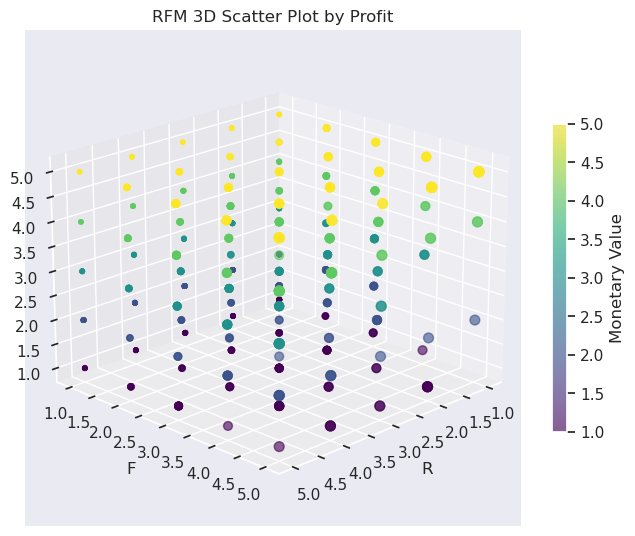

In [43]:
# 1. 创建图形和3D坐标轴
fig = plt.figure(figsize=(8, 8)) # 可以调整图形大小
ax = fig.add_subplot(111, projection='3d')

# 2. 绘制散点图
# 使用ax.scatter，分别传入R, F, M的值作为x, y, z坐标。
# 参数c可以指定颜色映射的依据，这里我们用'M'值（消费金额），让颜色代表客户价值高低。
# 参数cmap选择颜色映射，例如'viridis'。
# 参数s可以指定点的大小。
scatter = ax.scatter(rfm2['R_Score'], rfm2['F_Score'], rfm2['M_Score_Profit'],
                     c=rfm2['M_Score_Profit'], cmap='viridis', s=rfm2['F_Score']*10, alpha=0.6) # s和alpha可调整

# 3. 设置坐标轴标签
ax.set_xlabel('R')
ax.set_ylabel('F')
ax.set_zlabel('M')
ax.set_title('RFM 3D Scatter Plot by Profit')

# 4. 添加颜色条，显示Monetary值的映射
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label('Monetary Value')

# 5. 调整视角（可选）
ax.view_init(elev=20, azim=45) # 调整仰角和方位角以获得最佳视角

# 6. 显示图形
plt.show()

In [44]:
from sklearn.cluster import KMeans

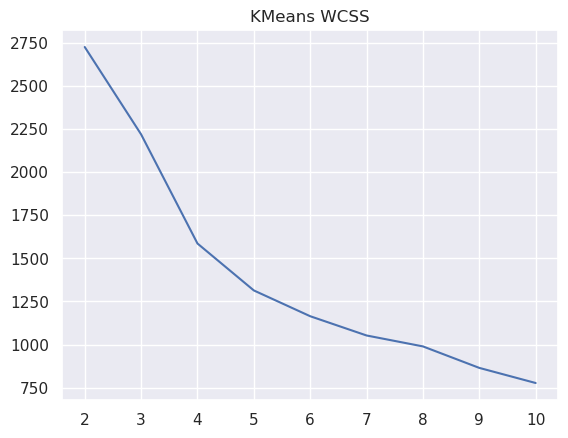

In [45]:
wcss = []
for i in range(2,11):
    kms = KMeans(n_clusters=i, random_state=42)
    kms = kms.fit(rfm1[['R_Score', 'F_Score', 'M_Score_Sales']])
    wcss.append(kms.inertia_)
sns.lineplot(x=range(2,11), y=wcss)
plt.title('KMeans WCSS')
plt.show()

In [46]:
from sklearn.metrics import silhouette_score

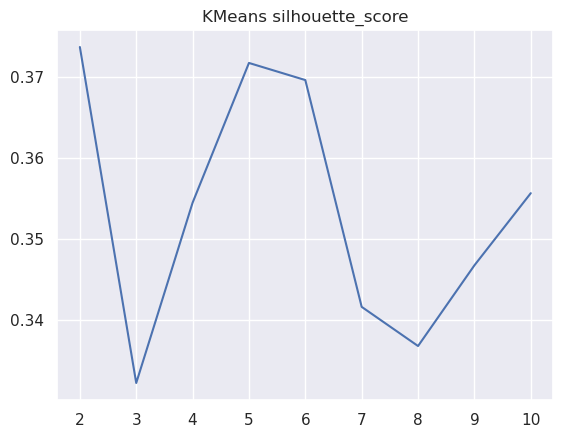

In [47]:
ss = []
for i in range(2,11):
    kms = KMeans(n_clusters=i, random_state=42)
    ylabel = kms.fit_predict(rfm1[['R_Score', 'F_Score', 'M_Score_Sales']])
    ss.append(silhouette_score(rfm1[['R_Score', 'F_Score', 'M_Score_Sales']], ylabel))

sns.lineplot(x=range(2,11), y=ss)
plt.title('KMeans silhouette_score')
plt.show()

In [48]:
kms = KMeans(n_clusters=4, random_state=42)
ylabel = kms.fit_predict(rfm1[['R_Score', 'F_Score', 'M_Score_Sales']])

In [49]:
result_sales = pd.DataFrame(kms.cluster_centers_, columns=['R','F','M']).sort_values(by=['R','F','M'])
result_sales.index=range(1,5)
result_sales

,R,F,M
1,1.395257,1.383399,1.588933
2,1.736842,3.710526,4.122807
3,3.908696,1.530435,1.756522
4,4.107143,3.428571,3.872449


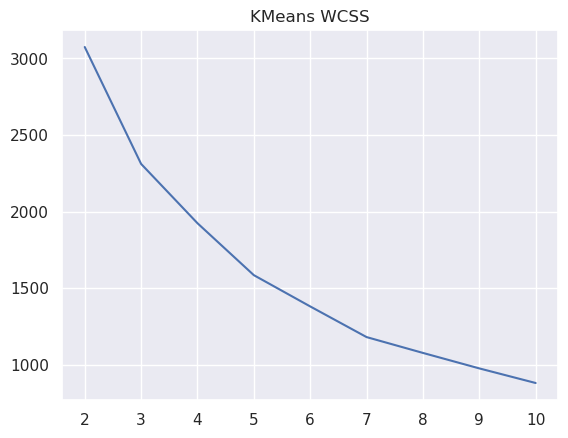

In [50]:
wcss = []
for i in range(2,11):
    kms = KMeans(n_clusters=i, random_state=42)
    kms = kms.fit(rfm2[['R_Score', 'F_Score', 'M_Score_Profit']])
    wcss.append(kms.inertia_)
sns.lineplot(x=range(2,11), y=wcss)
plt.title('KMeans WCSS')
plt.show()

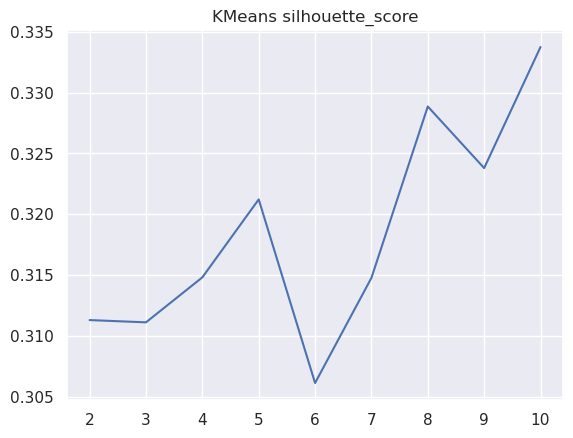

In [51]:
ss = []
for i in range(2,11):
    kms = KMeans(n_clusters=i, random_state=42)
    ylabel = kms.fit_predict(rfm2[['R_Score', 'F_Score', 'M_Score_Profit']])
    ss.append(silhouette_score(rfm2[['R_Score', 'F_Score', 'M_Score_Profit']], ylabel))

sns.lineplot(x=range(2,11), y=ss)
plt.title('KMeans silhouette_score')
plt.show()

In [52]:
kms = KMeans(n_clusters=4, random_state=42)
ylabel = kms.fit_predict(rfm2[['R_Score', 'F_Score', 'M_Score_Profit']])

In [53]:
result_profit = pd.DataFrame(kms.cluster_centers_, columns=['R','F','M']).sort_values(by=['R','F','M'])
result_profit.index=range(1,5)
result_profit

,R,F,M
1,1.716724,1.290102,1.952218
2,1.800000,3.528571,3.985714
3,4.056738,2.687943,4.439716
4,4.237443,2.493151,1.963470


In [54]:
result_profit.index = [1,2,4,3]

In [55]:
result_profit.sort_index()

,R,F,M
1,1.716724,1.290102,1.952218
2,1.800000,3.528571,3.985714
3,4.237443,2.493151,1.963470
4,4.056738,2.687943,4.439716


In [56]:
rfm1['Cluster'] = KMeans(n_clusters=4,random_state=42).fit_predict(rfm1[['R_Score', 'F_Score', 'M_Score_Sales']])
rfm2['Cluster'] = KMeans(n_clusters=4,random_state=42).fit_predict(rfm2[['R_Score', 'F_Score', 'M_Score_Profit']])

In [57]:
l1 = rfm1[rfm1['Cluster']==2]['Customer Name'].tolist()

In [58]:
l2 = rfm2[rfm2['Cluster']==3]['Customer Name'].tolist()

In [59]:
l1.extend(l2)

In [60]:
pd.Series(l1).unique()

array(['Seth Vernon', 'Brian Dahlen', 'Tom Boeckenhauer',
       'Shirley Daniels', 'Nathan Mautz', 'Sanjit Chand', 'Steven Roelle',
       'Tamara Manning', 'Sam Craven', 'Clay Ludtke', 'Craig Molinari',
       'Kean Thornton', 'Christine Phan', 'Matt Connell',
       'Cassandra Brandow', 'Thomas Seio', 'Jonathan Doherty',
       'Mark Packer', 'Nat Carroll', 'Alex Avila', 'Anna H鋌erlin',
       'Rob Dowd', 'Ken Black', 'Greg Maxwell', 'Ruben Dartt',
       'Scott Cohen', 'Edward Hooks', 'Stewart Visinsky',
       'Dorothy Badders', 'Laurel Beltran', 'Laura Armstrong',
       'Bill Shonely', 'Peter Fuller', 'Carol Triggs', 'Alejandro Grove',
       'Anthony Johnson', 'George Ashbrook', 'Randy Ferguson',
       'Dean percer', 'Dianna Wilson', 'Steven Cartwright',
       'Heather Kirkland', 'Pamela Stobb', 'Natalie Webber', 'Joel Eaton',
       'Grace Kelly', 'Noel Staavos', 'Cynthia Arntzen',
       'Maxwell Schwartz', 'Dennis Pardue', 'Becky Castell',
       'Darrin Sayre', 'Katherine

In [61]:
pd.Series(l1).nunique()

161